In [60]:
from pathlib import Path
from collections import Counter
from PIL import Image, ImageOps
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data Cleaning

In [61]:
PROJECT_DIR = Path.cwd()

In [7]:
CSV_PATH = Path("Dhan-Shomadhan/Dhan-Shomadhan_picture_Information.csv")

df = pd.read_csv(CSV_PATH)

print(df.shape)
print(df.columns.tolist())
print(df.info())
display(df.head())

(1106, 3)
['Unnamed: 0', 'pictureName', 'Diseases']
<class 'pandas.DataFrame'>
RangeIndex: 1106 entries, 0 to 1105
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Unnamed: 0   1106 non-null   int64
 1   pictureName  1106 non-null   str  
 2   Diseases     1106 non-null   str  
dtypes: int64(1), str(2)
memory usage: 26.1 KB
None


,Unnamed: 0,pictureName,Diseases
0,0,bsf_0.jpg,Browon Spot(Feild Background)
1,1,bsf_1.jpg,Browon Spot(Feild Background)
2,2,bsf_10.jpg,Browon Spot(Feild Background)
3,3,bsf_11.jpg,Browon Spot(Feild Background)
4,4,bsf_12.jpg,Browon Spot(Feild Background)


In [8]:
print(df["Diseases"].value_counts())

Diseases
Shath Blight(white Background)     219
Rice Blast(white Background)       198
Leaf Scaled(white Background)      143
Rice Tungro(white Background)      119
Brown Spot(white Background)        90
Rice Turgro(Feild Background)       76
Leaf Scaled(Feild Background)       74
Rice Blast(Feild Background)        74
Sheath Blight(Feild Background)     64
Browon Spot(Feild Background)       49
Name: count, dtype: int64


In [23]:
label_mapping = {
    "Shath Blight(white Background)": ("Sheath Blight", "white"),
    "Rice Blast(white Background)": ("Rice Blast", "white"),
    "Leaf Scaled(white Background)": ("Leaf Scald", "white"),
    "Rice Tungro(white Background)": ("Rice Tungro", "white"),
    "Brown Spot(white Background)": ("Brown Spot", "white"),
    
    "Rice Turgro(Feild Background)": ("Rice Tungro", "field"),
    "Leaf Scaled(Feild Background)": ("Leaf Scald", "field"),
    "Rice Blast(Feild Background)": ("Rice Blast", "field"),
    "Sheath Blight(Feild Background)": ("Sheath Blight", "field"),
    "Browon Spot(Feild Background)": ("Brown Spot", "field"),
}

df[["class", "domain"]] = pd.DataFrame(
    df["Diseases"]
    .map(lambda value: label_mapping.get(value, (None, None)))
    .tolist(),
    index=df.index,
    columns=["class", "domain"],
)

df.head()

,Unnamed: 0,pictureName,Diseases,Background,class,domain
0,0,bsf_0.jpg,Browon Spot(Feild Background),field,Brown Spot,field
1,1,bsf_1.jpg,Browon Spot(Feild Background),field,Brown Spot,field
2,2,bsf_10.jpg,Browon Spot(Feild Background),field,Brown Spot,field
3,3,bsf_11.jpg,Browon Spot(Feild Background),field,Brown Spot,field
4,4,bsf_12.jpg,Browon Spot(Feild Background),field,Brown Spot,field


In [35]:
diseases = ['Brown Spot', 'Leaf Scaled', 'Rice Blast', 'Rice Turgro', 'Sheath Blight']
background = ["white", 'field']

results = {}

results["class"] = df["class"].value_counts().to_dict()
results["domain"] = df["domain"].value_counts().to_dict()
results["class_domain"] = df.groupby(["class", "domain"]).size().to_dict()

results

{'class': {'Sheath Blight': 283,
  'Rice Blast': 272,
  'Leaf Scald': 217,
  'Rice Tungro': 195,
  'Brown Spot': 139},
 'domain': {'white': 769, 'field': 337},
 'class_domain': {('Brown Spot', 'field'): 49,
  ('Brown Spot', 'white'): 90,
  ('Leaf Scald', 'field'): 74,
  ('Leaf Scald', 'white'): 143,
  ('Rice Blast', 'field'): 74,
  ('Rice Blast', 'white'): 198,
  ('Rice Tungro', 'field'): 76,
  ('Rice Tungro', 'white'): 119,
  ('Sheath Blight', 'field'): 64,
  ('Sheath Blight', 'white'): 219}}

# Collect image-level properties

In [37]:
image_records = []
image_files = [
    p for p in PROJECT_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png"}
]

for path in image_files:
    try:
        with Image.open(path) as img:
            image_records.append({
                "filename": path.name,
                "path": str(path),
                "format": img.format,
                "width": img.width,
                "height": img.height,
                "mode": img.mode,
                "aspect_ratio": img.width / img.height,
                "pixels": img.width * img.height,
            })
    except Exception as e:
        print(f"ERROR: {path} -> {e}")

image_df = pd.DataFrame(image_records)

print("Images successfully inspected:", len(image_df))

Images successfully inspected: 1106


In [41]:
print("Formats:")
print(image_df["format"].value_counts())

print("\nImage modes:")
print(image_df["mode"].value_counts())

print("\nDimensions:")
print(image_df[["width", "height"]].value_counts().head(20))

Formats:
format
JPEG    1106
Name: count, dtype: int64

Image modes:
mode
RGB    1106
Name: count, dtype: int64

Dimensions:
width  height
1952   4160      716
4160   1952      384
3264   1536        6
Name: count, dtype: int64


In [52]:
# Width and height descriptive statistics
print("Width:")
print(image_df["width"].describe())

print("\nHeight:")
print(image_df["height"].describe())

Width:
count    1106.000000
mean     2725.728752
std      1050.884438
min      1952.000000
25%      1952.000000
50%      1952.000000
75%      4160.000000
max      4160.000000
Name: width, dtype: float64

Height:
count    1106.000000
mean     3379.153707
std      1058.925555
min      1536.000000
25%      1952.000000
50%      4160.000000
75%      4160.000000
max      4160.000000
Name: height, dtype: float64


In [53]:
# Aspect ratio and resolution descriptive statistics
print("\nAspect ratio:")
print(image_df["aspect_ratio"].describe())

print("\nResolution (pixels):")
print(image_df["pixels"].describe())


Aspect ratio:
count    1106.000000
mean        1.055226
std         0.794355
min         0.469231
25%         0.469231
50%         0.469231
75%         2.131148
max         2.131148
Name: aspect_ratio, dtype: float64

Resolution (pixels):
count    1.106000e+03
mean     8.103466e+06
std      2.283120e+05
min      5.013504e+06
25%      8.120320e+06
50%      8.120320e+06
75%      8.120320e+06
max      8.120320e+06
Name: pixels, dtype: float64


In [50]:
# Min-max resolution images
print("Minimum resolution:",
      image_df.loc[image_df["pixels"].idxmin(), ["filename", "width", "height", "pixels"]].to_dict())

print("Maximum resolution:",
      image_df.loc[image_df["pixels"].idxmax(), ["filename", "width", "height", "pixels"]].to_dict())

Minimum resolution: {'filename': 'sbf_30.jpg', 'width': 3264, 'height': 1536, 'pixels': 5013504}
Maximum resolution: {'filename': 'sbf_18.jpg', 'width': 1952, 'height': 4160, 'pixels': 8120320}


In [ ]:
image_df["orientation"] = np.where(
    image_df["width"] > image_df["height"],
    "landscape",
    "portrait"
)

# Orientation by domain and class
display(
    pd.crosstab(
        image_df["domain"],
        image_df["orientation"]
    )
)

display(
    pd.crosstab(
        image_df["class"],
        image_df["orientation"]
    )
)

orientation,landscape,portrait
domain,,
field,27,310
white,363,406


orientation,landscape,portrait
class,,
Brown Spot,33,106
Leaf Scald,65,152
Rice Blast,80,192
Rice Tungro,40,155
Sheath Blight,172,111


In [55]:
sheath_landscape = image_df[
    (image_df["class"] == "Sheath Blight") &
    (image_df["orientation"] == "landscape")
]

print("Count:", len(sheath_landscape))

display(
    sheath_landscape[
        ["filename", "domain", "width", "height", "aspect_ratio", "orientation"]
    ].head(20)
)

Count: 172


,filename,domain,width,height,aspect_ratio,orientation
1,sbf_30.jpg,field,3264,1536,2.125000,landscape
4,sbf_31.jpg,field,3264,1536,2.125000,landscape
7,sbf_33.jpg,field,3264,1536,2.125000,landscape
8,sbf_32.jpg,field,3264,1536,2.125000,landscape
38,sbf_42.jpg,field,4160,1952,2.131148,landscape
62,sbf_29.jpg,field,3264,1536,2.125000,landscape
339,sb_wb_189.jpg,white,4160,1952,2.131148,landscape
340,sb_wb_162.jpg,white,4160,1952,2.131148,landscape
342,sb_wb_77.jpg,white,4160,1952,2.131148,landscape
343,sb_wb_63.jpg,white,4160,1952,2.131148,landscape


In [63]:
path = PROJECT_DIR / "Dhan-Shomadhan" / "Field Background  " / "Sheath Blight" / "sbf_30.jpg"

with Image.open(path) as img:
    print("Raw dimensions:", img.size)
    print("EXIF orientation:", img.getexif().get(274))

    corrected = ImageOps.exif_transpose(img)

    print("After EXIF transpose:", corrected.size)

Raw dimensions: (3264, 1536)
EXIF orientation: 6
After EXIF transpose: (1536, 3264)


The dataset contains JPEG EXIF orientation metadata. Raw pixel dimensions do not always represent the displayed image orientation; therefore, EXIF orientation must be applied before calculating visual dimensions, aspect ratios, or orientation.

In [64]:
image_records = []

for path in image_files:
    try:
        with Image.open(path) as img:
            raw_width, raw_height = img.size
            exif_orientation = img.getexif().get(274)

            corrected = ImageOps.exif_transpose(img)
            width, height = corrected.size

            image_records.append({
                "filename": path.name,
                "path": str(path),
                "format": img.format,
                "mode": img.mode,
                "raw_width": raw_width,
                "raw_height": raw_height,
                "width": width,
                "height": height,
                "aspect_ratio": width / height,
                "pixels": width * height,
                "exif_orientation": exif_orientation,
            })

    except Exception as e:
        print(f"ERROR: {path} -> {e}")

image_df = pd.DataFrame(image_records)

print("Images successfully inspected:", len(image_df))

Images successfully inspected: 1106


In [65]:
image_df = image_df.merge(
    df[["pictureName", "class", "domain"]],
    left_on="filename",
    right_on="pictureName",
    how="left"
)

print("Missing class:", image_df["class"].isna().sum())
print("Missing domain:", image_df["domain"].isna().sum())

Missing class: 0
Missing domain: 0


In [66]:
image_df["orientation"] = np.where(
    image_df["width"] > image_df["height"],
    "landscape",
    "portrait"
)

display(
    pd.crosstab(
        image_df["domain"],
        image_df["orientation"]
    )
)

orientation,landscape,portrait
domain,,
field,11,326
white,0,769


In [72]:
print(
    image_df["exif_orientation"]
    .value_counts(dropna=False)
    .sort_index()
)

exif_orientation
0    720
1      5
3      2
6    161
8    218
Name: count, dtype: int64


In [73]:
print(
    "Images affected by EXIF rotation:",
    image_df["exif_orientation"].isin([3, 5, 6, 7, 8]).sum()
)

Images affected by EXIF rotation: 381


381 / 1,106 images (34.4%) have EXIF rotation metadata. We need EXIF-aware image handling throughout the audit and later preprocessing.

In [76]:
# Corrected orientation after applying EXIF metadata

image_df["orientation"] = np.where(
    image_df["width"] > image_df["height"],
    "landscape",
    "portrait"
)

print("Orientation by domain:")
display(
    pd.crosstab(
        image_df["domain"],
        image_df["orientation"]
    )
)

print("Orientation by class:")
display(
    pd.crosstab(
        image_df["class"],
        image_df["orientation"]
    )
)

print("Corrected dimensions:")
display(
    image_df[["width", "height"]]
    .value_counts()
    .sort_index()
)

Orientation by domain:


orientation,landscape,portrait
domain,,
field,11,326
white,0,769


Orientation by class:


orientation,landscape,portrait
class,,
Brown Spot,1,138
Leaf Scald,1,216
Rice Blast,3,269
Rice Tungro,5,190
Sheath Blight,1,282


Corrected dimensions:


width  height
1536   3264         6
1952   4160      1089
4160   1952        11
Name: count, dtype: int64

In [77]:
print("Aspect ratio summary:")
display(
    image_df["aspect_ratio"].describe()
)

print("Most common aspect ratios:")
display(
    image_df["aspect_ratio"]
    .round(3)
    .value_counts()
    .head(15)
)

Aspect ratio summary:


count    1106.000000
mean        0.485767
std         0.164988
min         0.469231
25%         0.469231
50%         0.469231
75%         0.469231
max         2.131148
Name: aspect_ratio, dtype: float64

Most common aspect ratios:


aspect_ratio
0.469    1089
2.131      11
0.471       6
Name: count, dtype: int64

In [78]:
print("Resolution by domain:")
display(
    image_df.groupby("domain")[["width", "height", "pixels"]]
    .agg(["min", "max", "mean"])
)

Resolution by domain:


width                    height                      pixels           \
         min   max         mean    min   max         mean      min      max   
domain                                                                        
field   1536  4160  2016.664688   1952  4160  4071.976261  5013504  8120320   
white   1952  1952  1952.000000   4160  4160  4160.000000  8120320  8120320   

                      
                mean  
domain                
field   8.065006e+06  
white   8.120320e+06

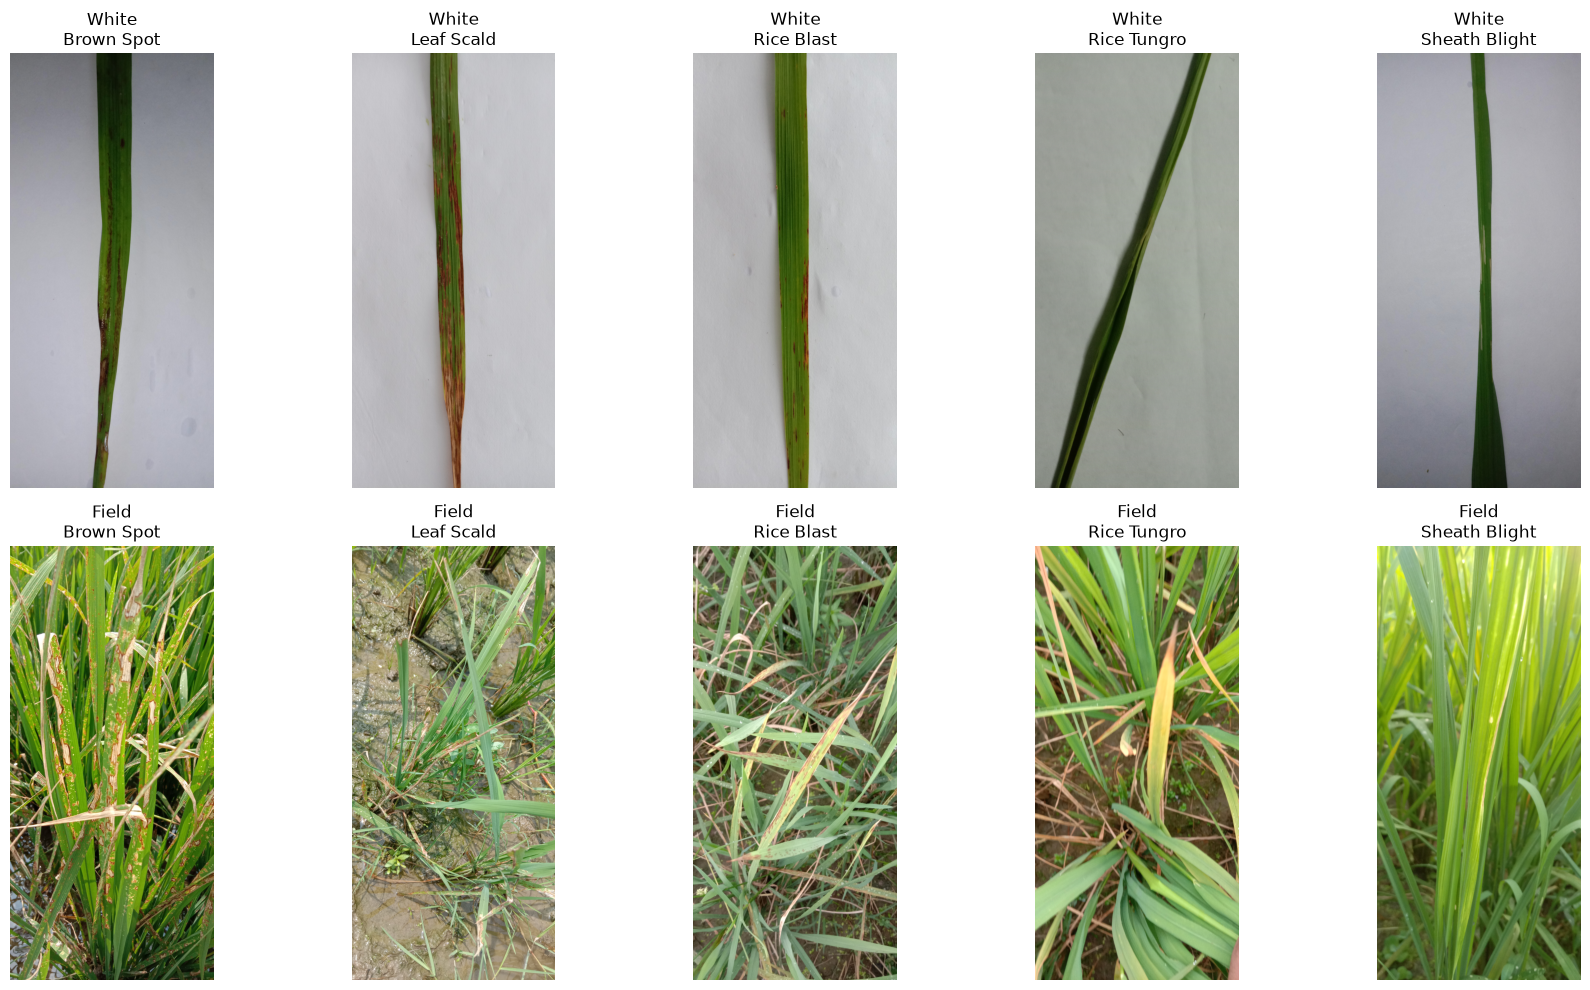

In [79]:
classes = [
    "Brown Spot",
    "Leaf Scald",
    "Rice Blast",
    "Rice Tungro",
    "Sheath Blight",
]

domains = ["white", "field"]

rng = np.random.default_rng(42)

fig, axes = plt.subplots(2, 5, figsize=(18, 10))

for row, domain in enumerate(domains):
    for col, class_name in enumerate(classes):

        subset = image_df[
            (image_df["domain"] == domain) &
            (image_df["class"] == class_name)
        ]

        row_idx = rng.choice(subset.index)
        record = image_df.loc[row_idx]

        # Important: correct EXIF orientation before displaying
        with Image.open(record["path"]) as img:
            img = ImageOps.exif_transpose(img)

            axes[row, col].imshow(img)

        axes[row, col].set_title(
            f"{domain.title()}\n{class_name}"
        )
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

## Visual Audit Findings

The white-background and field-background subsets have substantially different visual characteristics.

### Field-background images

- Multiple rice leaves are frequently visible.
- Leaves commonly overlap each other and surrounding vegetation.
- The apparent target leaf is often thin and occupies only approximately 10–15% of the image.
- The intended target leaf is not always immediately obvious.
- Disease symptoms may occupy a very small portion of the image and can be difficult to identify visually.
- Sheath Blight appears particularly difficult to distinguish in some samples.
- Brown Spot and Rice Blast can exhibit visually similar brownish symptom patterns.

### Implications

The field-background subset introduces a substantial localization and background-variation challenge in addition to the classification problem.

A model trained directly on the full image may potentially exploit background/contextual features rather than disease-specific visual features.

This motivates investigating whether leaf localization or segmentation can improve robustness, particularly when transferring knowledge from the controlled white-background subset to field-background images.